In [217]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [218]:
base_df=pd.read_csv('Churn_Modelling_EDA.csv')
base_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [219]:
base_df.shape

(7043, 21)

In [220]:
base_df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [221]:
base_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [222]:
base_df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [223]:
base_df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

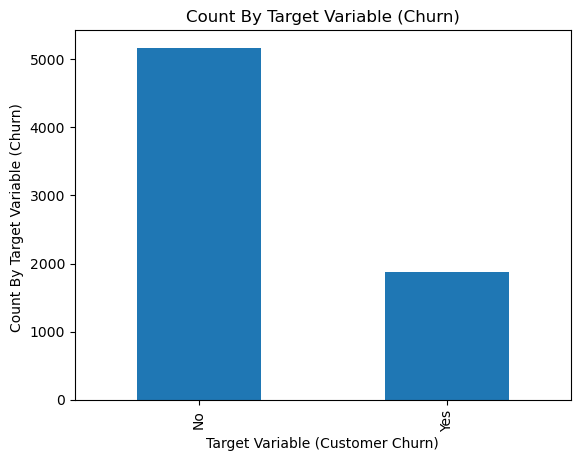

In [224]:
base_df['Churn'].value_counts().plot(kind='bar')
plt.xlabel('Target Variable (Customer Churn)')
plt.ylabel('Count By Target Variable (Churn) ')
plt.title('Count By Target Variable (Churn)')
plt.show()

In [225]:
#Churn Percentage
(base_df['Churn'].value_counts()/base_df['Churn'].shape[0])*100

Churn
No     73.463013
Yes    26.536987
Name: count, dtype: float64

Data is imbalanced based on target varaible churn 26% churn and 73% not churn customers.

In [226]:
#Missing Values

In [227]:
base_df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [228]:
#Data Cleaning

In [229]:
base_df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [230]:
#Convert TotalCharges to int and replace non-integer values to nan

In [231]:
base_df['TotalCharges']=pd.to_numeric(base_df['TotalCharges'], errors='coerce')


In [232]:
base_df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

11 missing values in total charges after converting them to numeric field.
Let use see the 11 records.

In [233]:
base_df[base_df['TotalCharges'].isnull()==True]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


# Missing Value Treatment
Since the number of records are low 0.15% we ignore them from futher processing.

In [234]:
base_df.dropna(inplace=True, axis=0)

In [235]:
base_df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [236]:
base_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [237]:
#converting tenure to bins

In [238]:
base_df['tenure'].unique()

array([ 1, 34,  2, 45,  8, 22, 10, 28, 62, 13, 16, 58, 49, 25, 69, 52, 71,
       21, 12, 30, 47, 72, 17, 27,  5, 46, 11, 70, 63, 43, 15, 60, 18, 66,
        9,  3, 31, 50, 64, 56,  7, 42, 35, 48, 29, 65, 38, 68, 32, 55, 37,
       36, 41,  6,  4, 33, 67, 23, 57, 61, 14, 20, 53, 40, 59, 24, 44, 19,
       54, 51, 26, 39])

In [239]:
base_df['tenure'].min()

1

In [240]:
base_df['tenure'].max()

72

In [241]:
labels = [f" {i}-{i+11} "for i in range(1,72,12)]
labels

[' 1-12 ', ' 13-24 ', ' 25-36 ', ' 37-48 ', ' 49-60 ', ' 61-72 ']

In [242]:
base_df['tenure']=pd.cut(x=base_df['tenure'],bins=range(1,80,12),labels=labels,right=False)

In [243]:
base_df['tenure'].value_counts()

tenure
1-12      2175
61-72     1407
13-24     1024
25-36      832
49-60      832
37-48      762
Name: count, dtype: int64

In [244]:
#Drop Columns not required for processing

In [245]:
base_df.drop(columns=['customerID','tenure'],inplace=True, axis=1)
base_df.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [246]:
base_df['Churn']=np.where(base_df['Churn'] == 'Yes', 1, 0)
base_df['Churn'].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [247]:
#Creating copy of base_df

In [248]:
final_df=base_df

In [249]:
#converting categorical variables into dummy variables - similar to one hot encoding


In [181]:
df=pd.get_dummies(base_df)
df.head()

,SeniorCitizen,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,29.85,29.85,0,True,False,False,True,True,False,...,False,True,False,False,False,True,False,False,True,False
1,0,56.95,1889.50,0,False,True,True,False,True,False,...,False,False,True,False,True,False,False,False,False,True
2,0,53.85,108.15,1,False,True,True,False,True,False,...,False,True,False,False,False,True,False,False,False,True
3,0,42.30,1840.75,0,False,True,True,False,True,False,...,False,False,True,False,True,False,True,False,False,False
4,0,70.70,151.65,1,True,False,True,False,True,False,...,False,True,False,False,False,True,False,False,True,False


In [182]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 45 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   SeniorCitizen                            7032 non-null   int64  
 1   MonthlyCharges                           7032 non-null   float64
 2   TotalCharges                             7032 non-null   float64
 3   Churn                                    7032 non-null   int64  
 4   gender_Female                            7032 non-null   bool   
 5   gender_Male                              7032 non-null   bool   
 6   Partner_No                               7032 non-null   bool   
 7   Partner_Yes                              7032 non-null   bool   
 8   Dependents_No                            7032 non-null   bool   
 9   Dependents_Yes                           7032 non-null   bool   
 10  PhoneService_No                          7032 non-nul

In [183]:
#Relationship between monthly charges and total charges

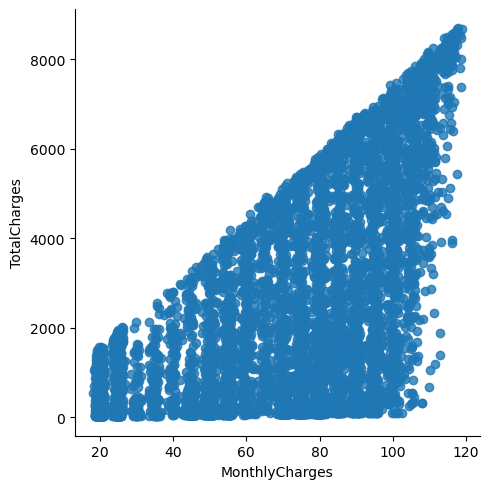

In [184]:
sns.lmplot(data=df, x='MonthlyCharges', y='TotalCharges', fit_reg=False)

### Insight from Scatter Plot: Monthly Charges vs Total Charges

The scatter plot shows the relationship between `MonthlyCharges` and `TotalCharges`.

#### Key Insights

- There is a strong positive relationship between `MonthlyCharges` and `TotalCharges`.
- As monthly charges increase, total charges also tend to increase.
- Customers with higher monthly plans generally accumulate higher total charges over time.
- The triangular spread pattern suggests that customers with similar monthly charges may have different tenures.
- Customers with low total charges but high monthly charges are likely newer customers who recently joined the service.
- Customers with high total charges are likely long-term customers who have stayed with the company for a longer duration.
- The dense concentration of points in the lower total charge region indicates that many customers have relatively lower accumulated charges.
- No major extreme outliers are observed in the dataset.

#### Additional Observation

Since:

TotalCharges ≈ MonthlyCharges × Tenure

this plot indirectly suggests that tenure may also play an important role in customer behavior and churn analysis.

In [191]:
#Churn vs monthly charges

<Axes: xlabel='MonthlyCharges', ylabel='Density'>

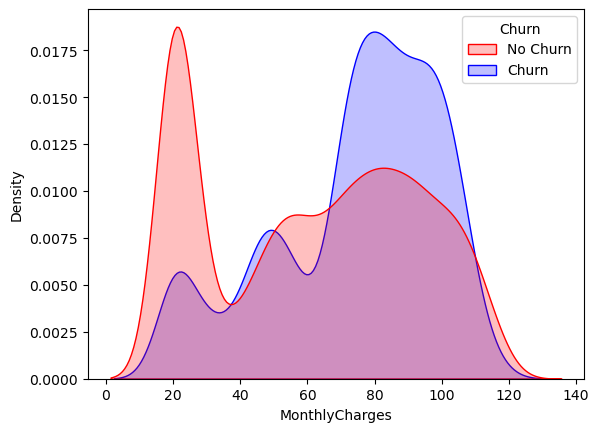

In [189]:
sns.kdeplot(data=df, x='MonthlyCharges', hue=df['Churn'].map({0:'No Churn',1:'Churn'}), palette=['red','blue'], fill=True, common_norm=False)

### Insight from KDE Plot: Monthly Charges vs Churn

The KDE plot compares the distribution of `MonthlyCharges` between churned and non-churned customers.

#### Key Insights

- Customers with higher monthly charges are more likely to churn.
- Churned customers are highly concentrated in the monthly charge range of approximately  **$70–$100**.
- Non-churn customers show a strong concentration around lower monthly charges, especially near  **$20–$30**.
- This suggests that customers with lower-cost plans tend to stay longer, while customers paying higher charges may be more likely to leave the service.
- There is still overlap between churn and non-churn customers, indicating that `MonthlyCharges` alone cannot fully explain customer churn.
- Additional factors such as contract type, tenure, internet service, payment method, and customer support may also influence churn behavior.

#### About `common_norm=False`

The parameter `common_norm=False` normalizes each churn category separately instead of using a common normalization across all groups.

This helps provide a fair comparison because telecom churn datasets are usually imbalanced, with significantly more non-churn customers than churn customers.

In [192]:
#Churn Vs Total Charges

<Axes: xlabel='TotalCharges', ylabel='Density'>

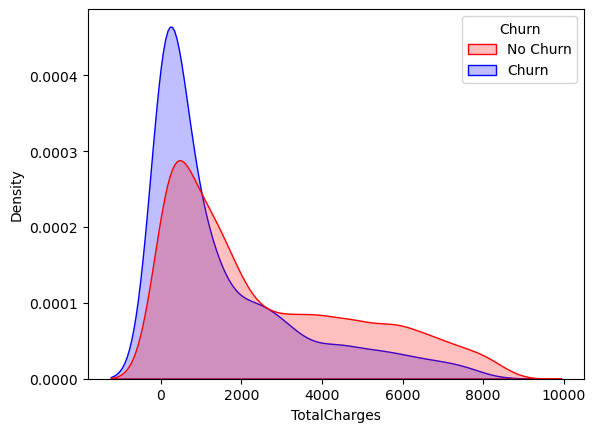

In [193]:
sns.kdeplot(data=df, x='TotalCharges', hue=df['Churn'].map({0:'No Churn',1:'Churn'}), palette=['red','blue'], fill=True, common_norm=False)

### Insight from KDE Plot: Total Charges vs Churn

The KDE plot compares the distribution of `TotalCharges` between churned and non-churned customers.

#### Key Insights

- Customers with lower total charges are more likely to churn.
- Churned customers show a strong concentration in the lower total charge range, especially below approximately **$1000–$1500**.
- Non-churn customers have a wider distribution and are more concentrated in higher total charge ranges.
- Customers with very high total charges are less likely to churn, indicating that long-term customers tend to stay with the company.
- Since `TotalCharges` accumulates over time, this suggests that newer customers are more likely to churn compared to long-term customers.
- The plot indirectly indicates that customer tenure may play a significant role in churn behavior.

#### Business Interpretation

This pattern suggests that customer churn is highest during the early stages of the customer lifecycle. Customers who remain with the company longer tend to accumulate higher total charges and are generally more loyal.

#### About `common_norm=False`

The parameter `common_norm=False` normalizes each churn category separately.

This helps compare the distributions fairly because the dataset contains more non-churn customers than churn customers.

In [194]:
#Correlation of churn vs independent variable

Text(0.5, 1.0, 'Correlation With Churn')

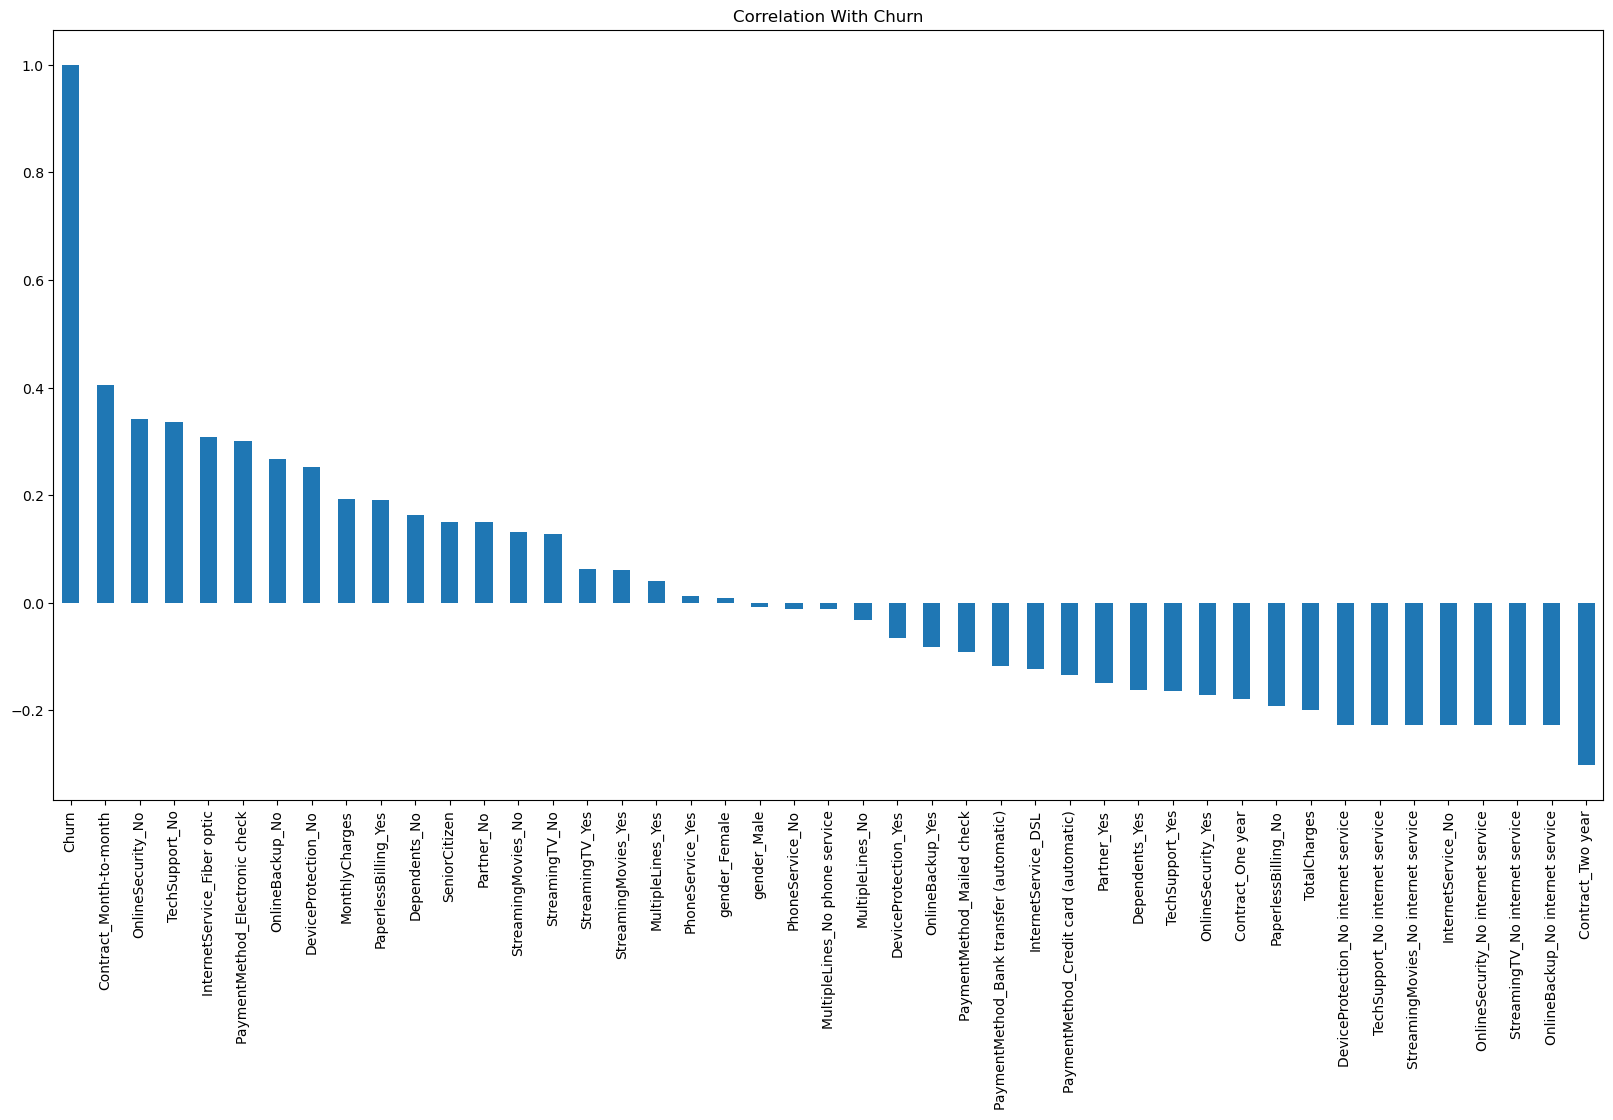

In [203]:
plt.figure(figsize=(20,10))
df.corr()['Churn'].sort_values(ascending=False).plot(kind='bar')
plt.title('Correlation With Churn')

### Insight from Correlation Bar Plot with Churn

The bar plot shows the correlation of all features with the target variable `Churn`.

Positive values indicate features associated with higher churn, while negative values indicate features associated with lower churn and better customer retention.

---

## Features Strongly Positively Correlated with Churn

### 1. `Contract_Month-to-month`
- This has one of the strongest positive correlations with churn.
- Customers with month-to-month contracts are more likely to leave because they are not tied to long-term agreements.

### 2. `OnlineSecurity_No`
- Customers without online security services are more likely to churn.
- This suggests that customers using fewer value-added services may have weaker engagement with the company.

### 3. `TechSupport_No`
- Customers without technical support tend to churn more frequently.
- Technical support may improve customer satisfaction and retention.

### 4. `InternetService_Fiber optic`
- Fiber optic customers show higher churn behavior.
- Possible reasons may include higher pricing, service expectations, or competitive alternatives.

### 5. `PaymentMethod_Electronic check`
- Customers paying through electronic check appear to have higher churn rates.

### 6. `MonthlyCharges`
- Higher monthly charges are positively associated with churn.
- Customers paying more may be more price-sensitive or dissatisfied with service value.

### 7. `PaperlessBilling_Yes`
- Customers using paperless billing show slightly higher churn behavior.
- This may reflect customer segments that prefer flexible or digital-first services.

---

## Features Negatively Correlated with Churn

### 1. `Contract_Two year`
- This has one of the strongest negative correlations with churn.
- Customers on long-term contracts are much more likely to stay.

### 2. `TotalCharges`
- Customers with higher total charges are less likely to churn.
- Since total charges accumulate over time, this suggests long-term customers are more loyal.

### 3. `OnlineSecurity_Yes`
- Customers using online security services tend to remain with the company.

### 4. `TechSupport_Yes`
- Customers with tech support services have lower churn rates.
- Support services may improve customer experience and trust.

### 5. `InternetService_No`
- Customers without internet service appear less likely to churn, possibly because they rely on basic telecom services only.

### 6. `Dependents_Yes` and `Partner_Yes`
- Customers with dependents or partners tend to churn less.
- These customers may prefer service stability and long-term plans.

---

## Features with Near-Zero Correlation

Features such as:
- `gender_Male`
- `gender_Female`
- `PhoneService_Yes`

show very low correlation with churn.

This suggests these variables may not strongly influence customer churn behavior individually.

---

## Overall Business Interpretation

The analysis suggests that churn is strongly influenced by:

- Contract type
- Pricing
- Customer tenure
- Internet and support services
- Payment methods

Customers with flexible contracts, higher monthly costs, and fewer support/security services are more likely to churn.

Customers with long-term contracts, higher accumulated spending, and additional support services tend to remain loyal.

---

## Important Note

Correlation only measures linear association and does not imply causation.

A feature with high correlation may not necessarily cause churn. Further statistical analysis or machine learning models are needed to determine true predictive importance.

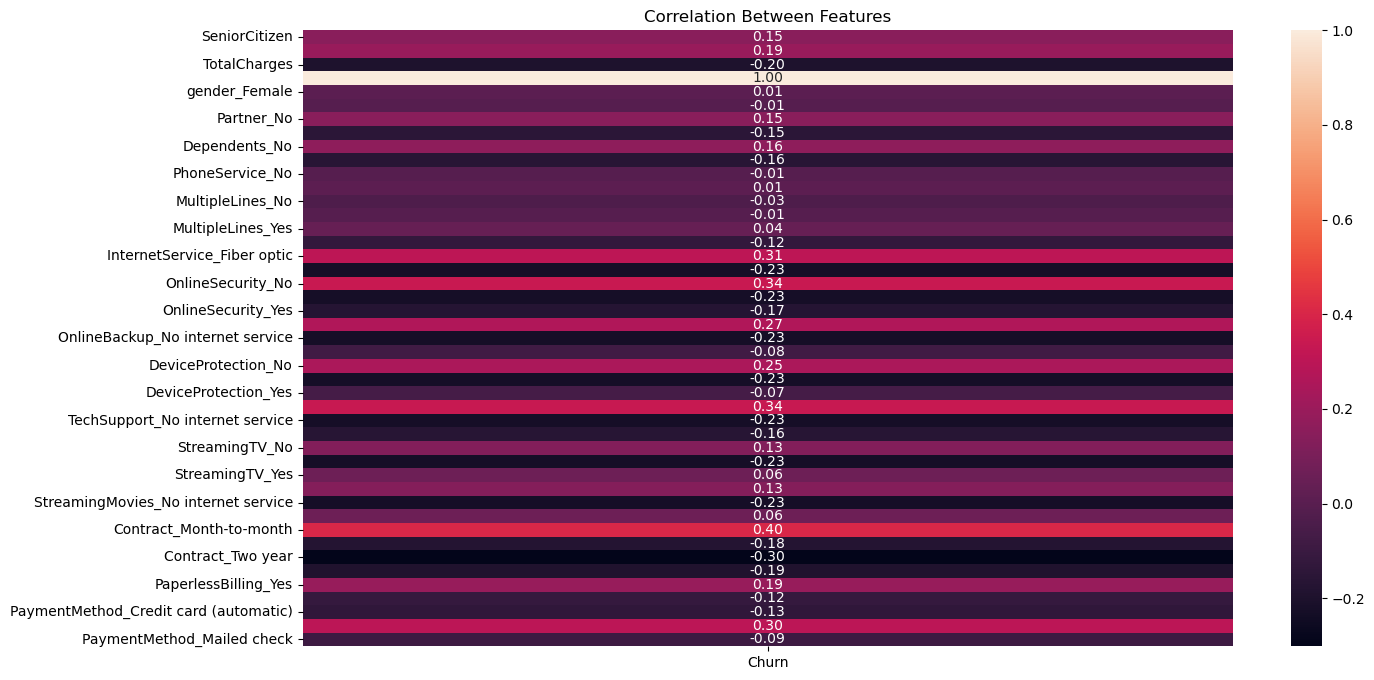

In [207]:
plt.figure(figsize=(15,8))
sns.heatmap(df.corr()[['Churn']], annot=True, fmt='.2f')
plt.title('Correlation Between Features')
plt.show()

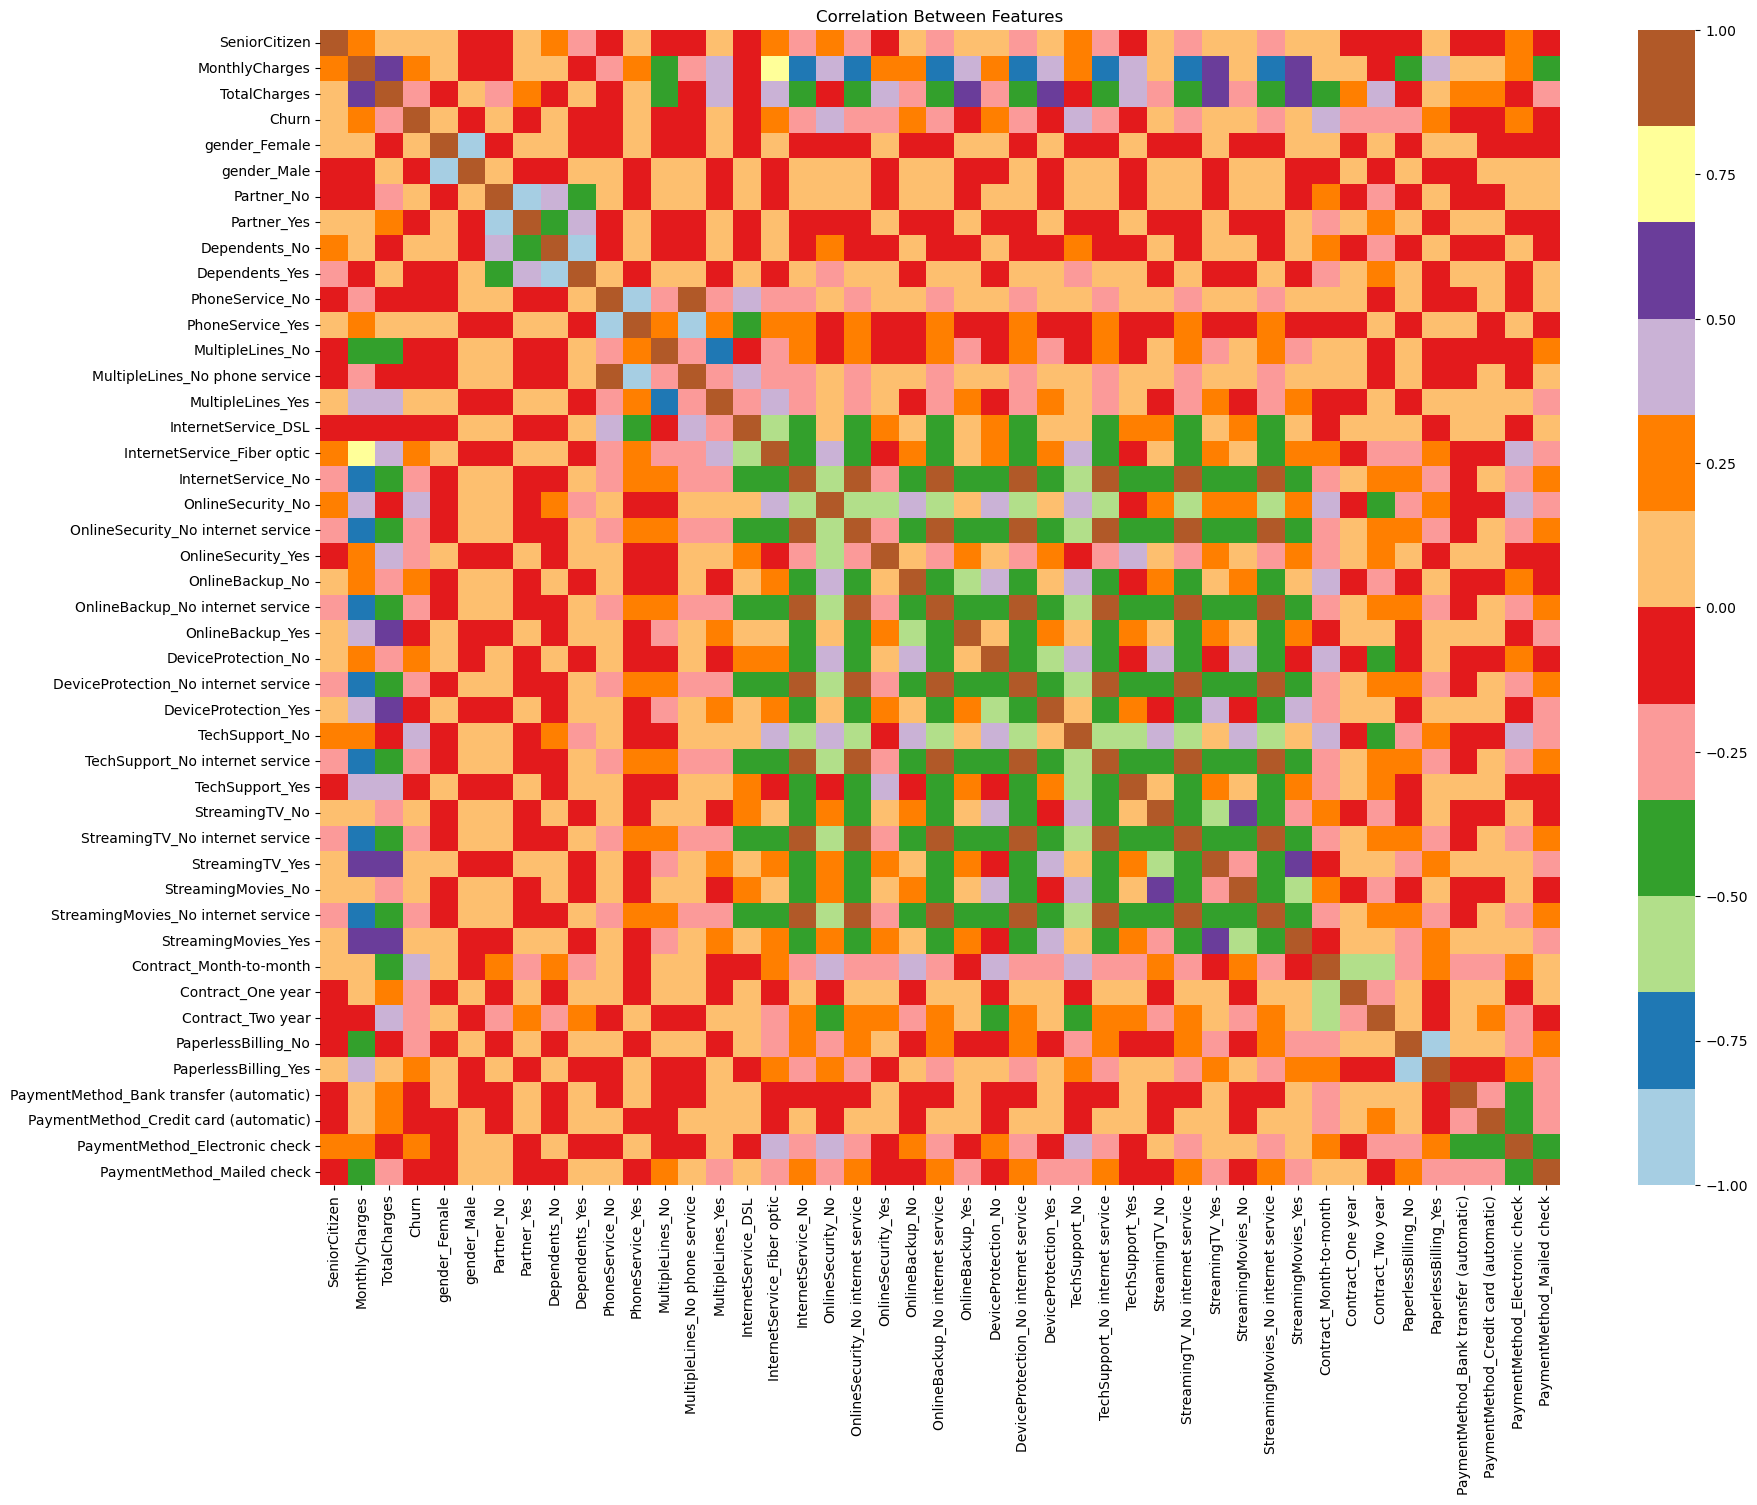

In [212]:
#correlation between all features using an heatmap
plt.figure(figsize=(20,15))
sns.heatmap(df.corr(), cmap='Paired')
plt.title('Correlation Between Features')
plt.show()

In [213]:
#Bivarient analysis

In [251]:
final_df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'],
      dtype='object')

In [255]:
final_df.head(2)

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0


In [261]:
#Partner, Gender, Churn

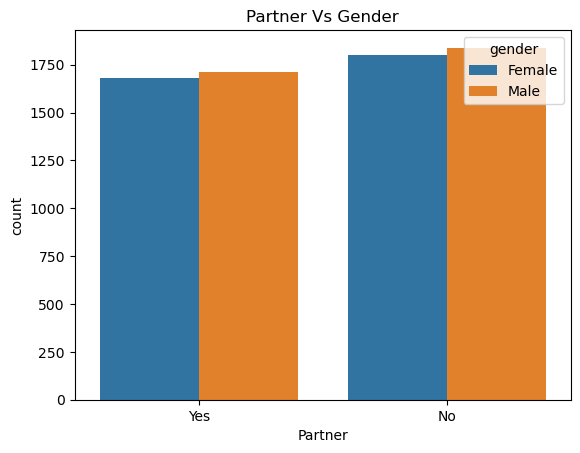

In [254]:
sns.countplot(final_df,x='Partner',hue='gender')
plt.title('Partner Vs Gender')
plt.show()

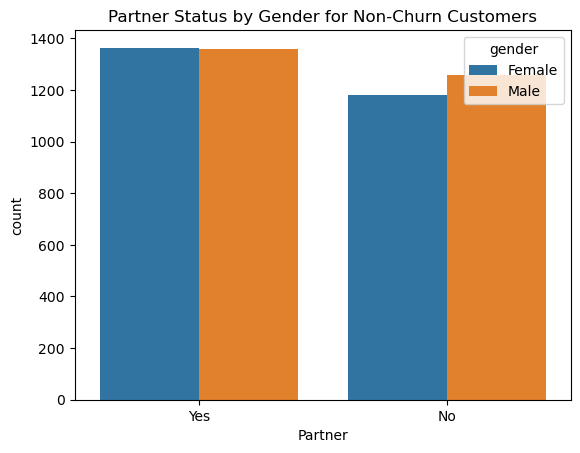

In [270]:
sns.countplot(final_df[final_df['Churn']==0],x='Partner',hue='gender')
plt.title('Partner Status by Gender for Non-Churn Customers')
plt.show()

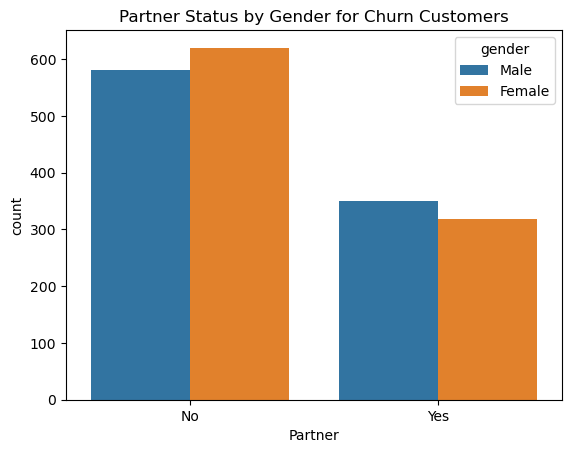

In [260]:
sns.countplot(final_df[final_df['Churn']==1],x='Partner',hue='gender')
plt.title('Partner Status by Gender for Churn Customers')
plt.show()

In [262]:
#Payment Method, Gender, Churn

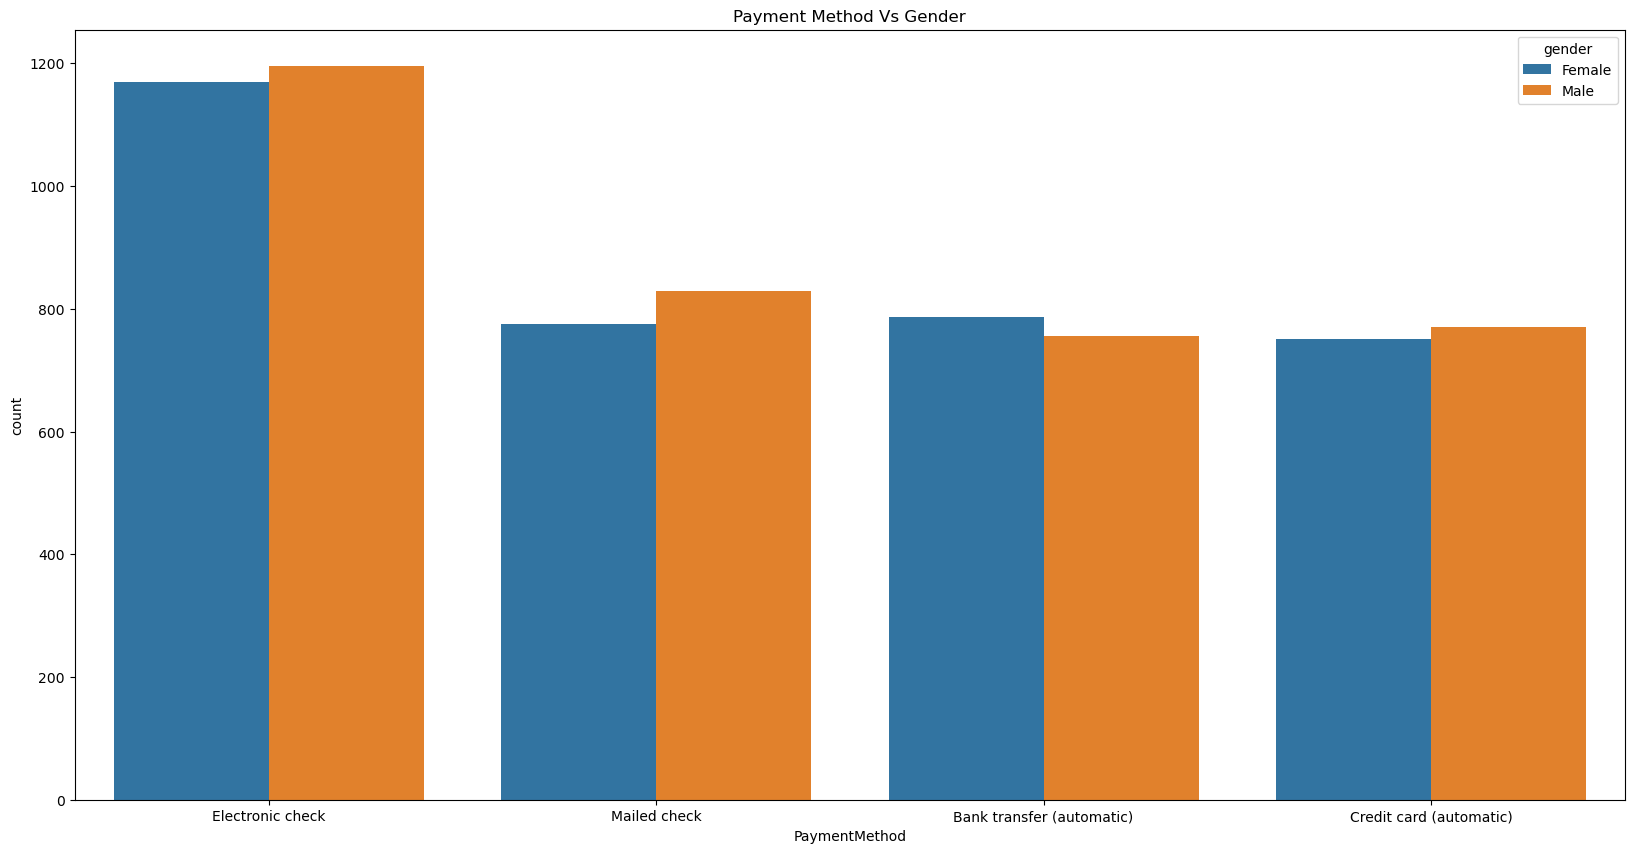

In [267]:
plt.figure(figsize=(20,10))
sns.countplot(final_df,x='PaymentMethod',hue='gender')
plt.title('Payment Method Vs Gender')
plt.show()

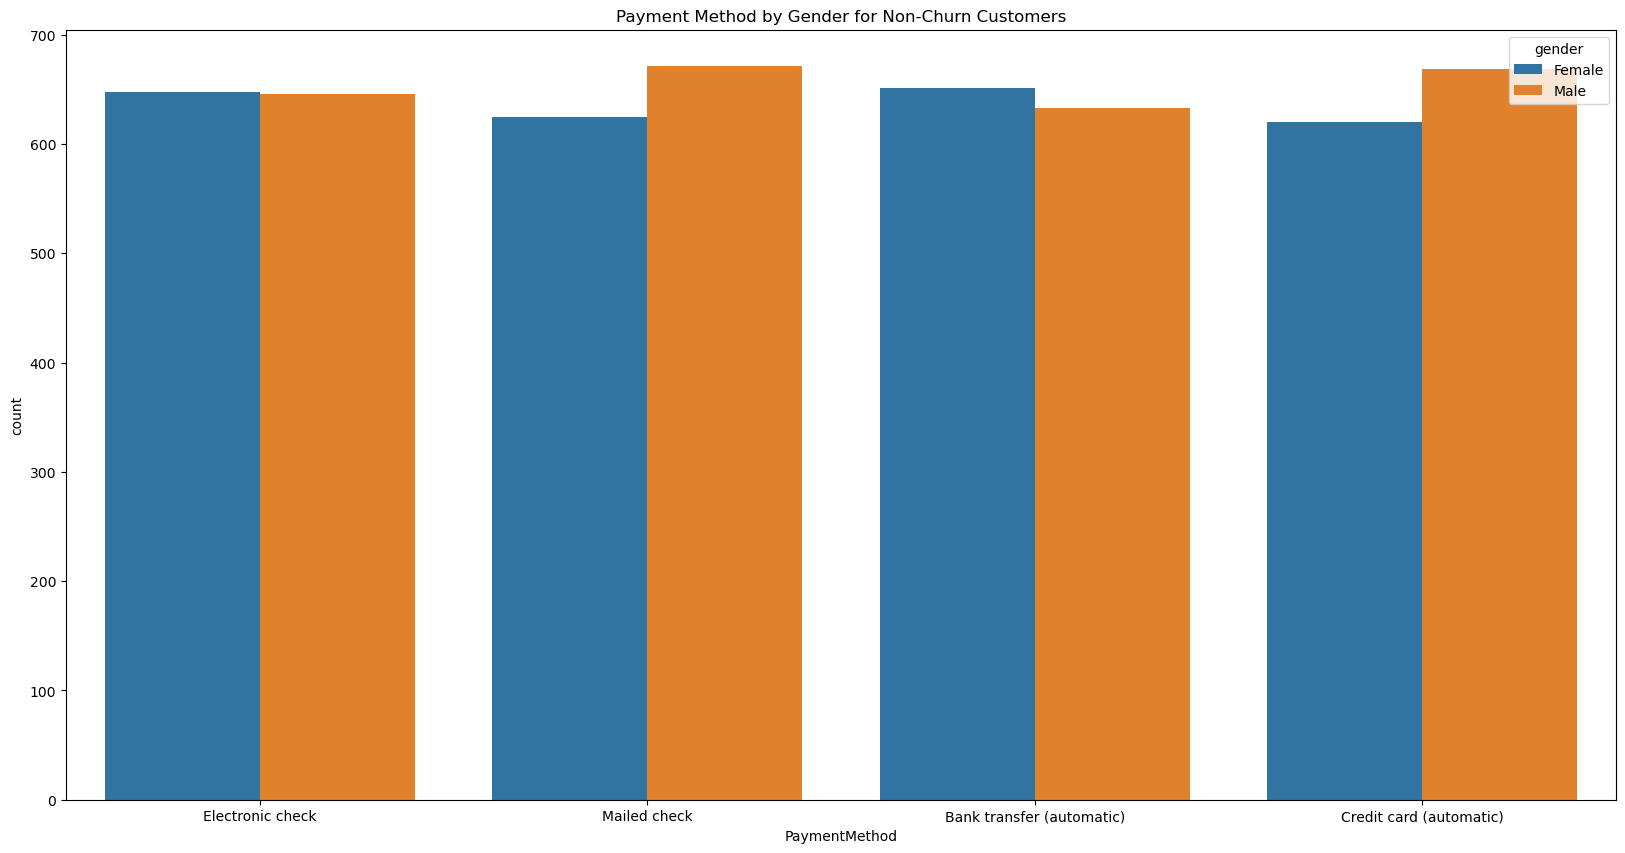

In [266]:
plt.figure(figsize=(20,10))
sns.countplot(final_df[final_df['Churn']==0],x='PaymentMethod',hue='gender')
plt.title('Payment Method by Gender for Non-Churn Customers')
plt.show()

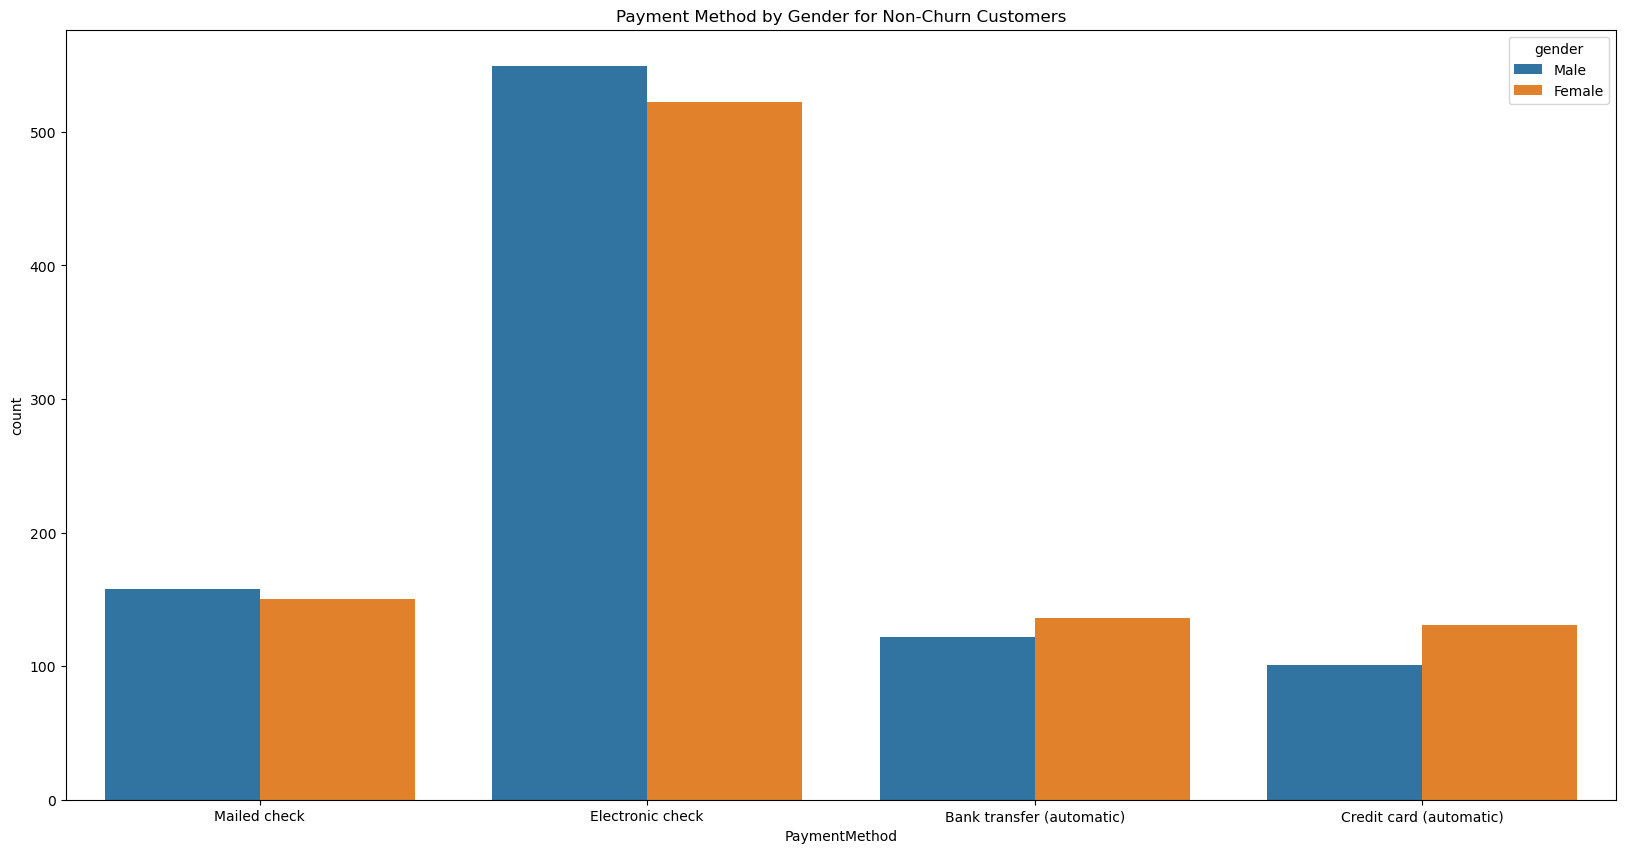

In [268]:
plt.figure(figsize=(20,10))
sns.countplot(final_df[final_df['Churn']==1],x='PaymentMethod',hue='gender')
plt.title('Payment Method by Gender for Non-Churn Customers')
plt.show()

In [271]:
#contract, gender, churn

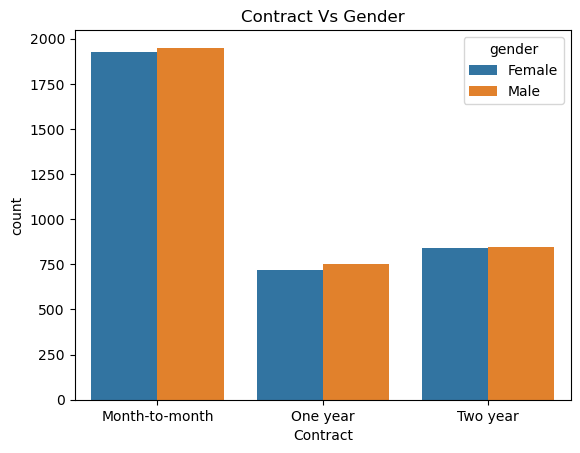

In [272]:
sns.countplot(final_df,x='Contract',hue='gender')
plt.title('Contract Vs Gender')
plt.show()

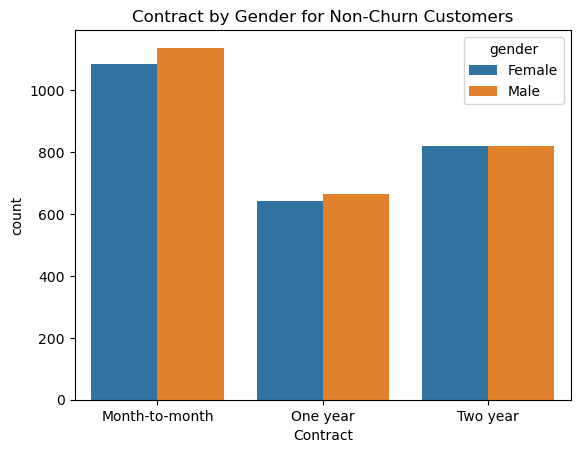

In [273]:
sns.countplot(final_df[final_df['Churn']==0],x='Contract',hue='gender')
plt.title('Contract by Gender for Non-Churn Customers')
plt.show()

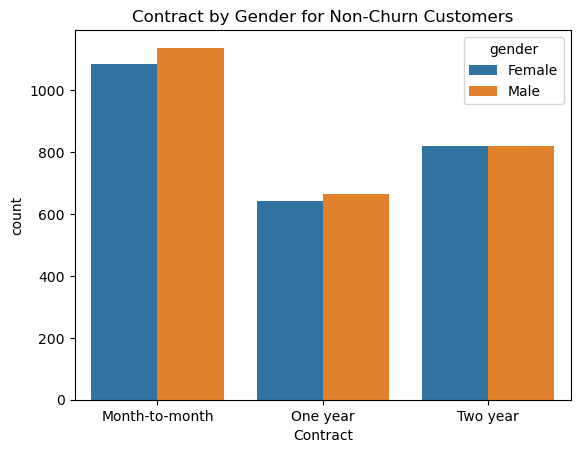

In [274]:
sns.countplot(final_df[final_df['Churn']==0],x='Contract',hue='gender')
plt.title('Contract by Gender for Non-Churn Customers')
plt.show()